In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.inspection import permutation_importance
from sklearn.metrics import(
    roc_auc_score, average_precision_score, brier_score_loss, log_loss, confusion_matrix, classification_report, RocCurveDisplay, PrecisionRecallDisplay, accuracy_score, f1_score, recall_score, precision_score
)

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

from imblearn.pipeline import Pipeline as IbmPipeline
from imblearn.over_sampling import SMOTE
from imblearn.ensemble import BalancedRandomForestClassifier

from scipy.stats import chi2_contingency, ttest_ind

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

import warnings
warnings.filterwarnings("ignore")

In [3]:
!kaggle competitions download -c playground-series-s6e3

  0% 0.00/14.9M [00:00<?, ?B/s]
100% 14.9M/14.9M [00:00<00:00, 1.53GB/s]


In [4]:
!unzip -q playground-series-s6e3.zip

In [5]:
df = pd.read_csv('train.csv')
df.head(1)

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,...,Yes,Yes,No,No,One year,Yes,Mailed check,60.1,1653.85,No


In [6]:
df.drop('id', axis=1, inplace=True)

print("Shape:", df.shape)

Shape: (594194, 20)


**Basic Checks**

In [7]:
df.info()

print("\nMissing values per column:")
display(df.isna().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   gender            594194 non-null  object 
 1   SeniorCitizen     594194 non-null  int64  
 2   Partner           594194 non-null  object 
 3   Dependents        594194 non-null  object 
 4   tenure            594194 non-null  int64  
 5   PhoneService      594194 non-null  object 
 6   MultipleLines     594194 non-null  object 
 7   InternetService   594194 non-null  object 
 8   OnlineSecurity    594194 non-null  object 
 9   OnlineBackup      594194 non-null  object 
 10  DeviceProtection  594194 non-null  object 
 11  TechSupport       594194 non-null  object 
 12  StreamingTV       594194 non-null  object 
 13  StreamingMovies   594194 non-null  object 
 14  Contract          594194 non-null  object 
 15  PaperlessBilling  594194 non-null  object 
 16  PaymentMethod     59

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


In [8]:
df['Churn'] = df['Churn'].map({'Yes' : 1, 'No' : 0})

In [9]:
display(df['Churn'].value_counts())
print("\nTarget rate (Churn=1):", df['Churn'].mean().round(4))

,count
Churn,
0,460377
1,133817



Target rate (Churn=1): 0.2252


In [10]:
x = df.drop('Churn', axis=1)
y = df['Churn'].astype(int)

cat_cols = x.select_dtypes('object').columns.to_list()
num_cols = [c for c in x.columns if c not in cat_cols]

print("Categorical cols:", cat_cols)
print("Numeric cols:", num_cols)

Categorical cols: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Numeric cols: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


In [11]:
for col in cat_cols:
    churn_rate = df.groupby(col)['Churn'].mean().sort_values(ascending=False)
    counts = df[col].value_counts()
    
    print(f"\nChurn rate by {col}:")
    display(pd.DataFrame({
        "Count" : counts,
        "Churn_rate" : churn_rate
    }))


Churn rate by gender:


,Count,Churn_rate
gender,,
Female,298738,0.228036
Male,295456,0.222348



Churn rate by Partner:


,Count,Churn_rate
Partner,,
No,284640,0.324621
Yes,309554,0.133796



Churn rate by Dependents:


...

,Count,Churn_rate
Contract,,
Month-to-month,298918,0.420543
One year,108333,0.057628
Two year,186943,0.009982



Churn rate by PaperlessBilling:


,Count,Churn_rate
PaperlessBilling,,
Yes,365579,0.319387
No,228615,0.074606



Churn rate by PaymentMethod:


,Count,Churn_rate
PaymentMethod,,
Bank transfer (automatic),121360,0.077093
Credit card (automatic),133705,0.069332
Electronic check,215372,0.489052
Mailed check,123757,0.079697


### Plots (distributions + correlations)

**Target distribution**

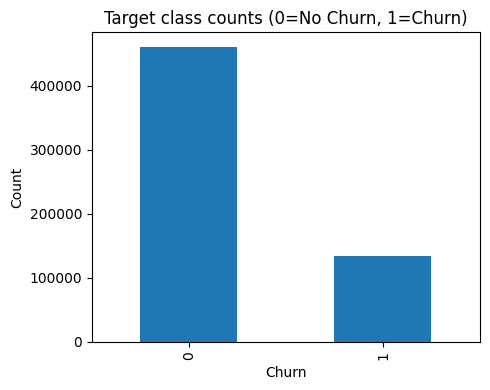

In [12]:
target_col = "Churn"
plt.figure(figsize=(5, 4))
df[target_col].value_counts().sort_index().plot(kind='bar')
plt.title("Target class counts (0=No Churn, 1=Churn)")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

**Histograms for numeric features**

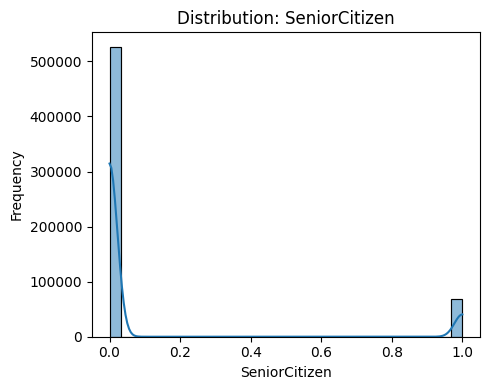

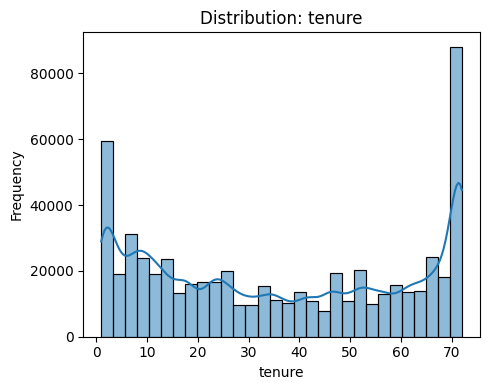

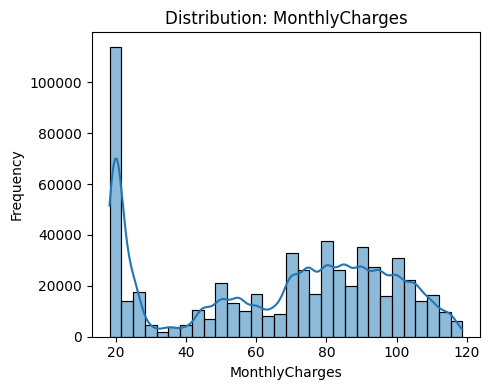

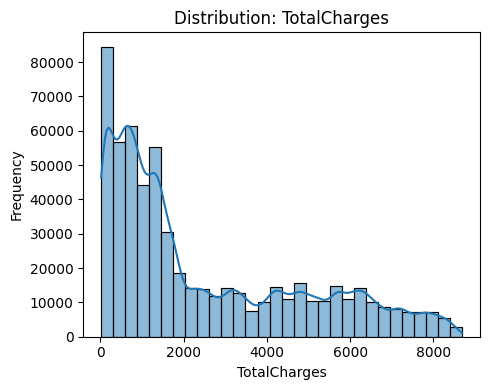

In [13]:
for col in num_cols:
    plt.figure(figsize=(5, 4))
    sns.histplot(data=df, x=col, kde=True, bins=30)
    plt.title(f"Distribution: {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

**Correlation**

In [14]:
corr = df[num_cols + [target_col]].corr()[target_col].sort_values(ascending=False)
display(corr.to_frame("corr_with_Churn"))

,corr_with_Churn
Churn,1.000000
MonthlyCharges,0.272997
SeniorCitizen,0.236362
TotalCharges,-0.218365
tenure,-0.418453


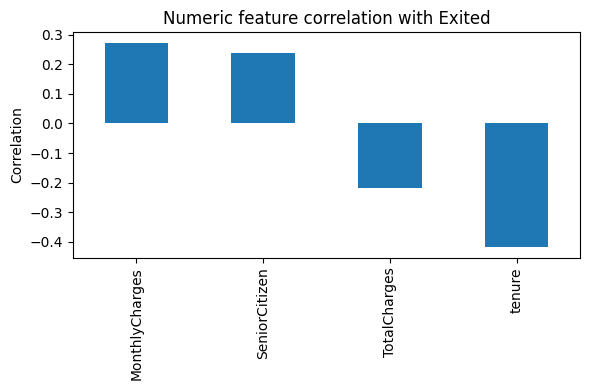

In [15]:
plt.figure(figsize=(6,4))
corr.drop(target_col).plot(kind="bar")
plt.title("Numeric feature correlation with Exited")
plt.ylabel("Correlation")
plt.tight_layout()
plt.show()

### statistical tests

**Chi-square tests for categorical columns**

In [16]:
chi_results = []
for col in cat_cols:
    ct = pd.crosstab(df[col], df[target_col])
    chi2, p, dof, expected = chi2_contingency(ct)
    chi_results.append((col, chi2, p, dof))

chi_df = pd.DataFrame(chi_results, columns=['feature', 'chi2', 'p_value', 'dof']).sort_values('p_value')
display(chi_df)

,feature,chi2,p_value,dof
1,Partner,30944.982146,0.000000e+00,1
2,Dependents,34329.594977,0.000000e+00,1
5,InternetService,107801.939664,0.000000e+00,2
4,MultipleLines,7888.570524,0.000000e+00,2
6,OnlineSecurity,108175.343877,0.000000e+00,2
7,OnlineBackup,79195.701242,0.000000e+00,2
9,TechSupport,103003.061768,0.000000e+00,2
8,DeviceProtection,72256.065155,0.000000e+00,2
12,Contract,132429.251778,0.000000e+00,2
13,PaperlessBilling,48298.222866,0.000000e+00,1


**Welch t-test for numeric columns**

In [17]:
ttest_results = []

for col in num_cols:
    a = df.loc[df[target_col]==0, col]
    b = df.loc[df[target_col]==1, col]
    t_stat, p = ttest_ind(a, b, equal_var=False)
    ttest_results.append((col, t_stat, p, a.mean(), b.mean()))
    
tt_df = pd.DataFrame(ttest_results, columns=["feature", "t_stat", "p_value", "mean_no_churn", "mean_churn"]).sort_values("p_value")

display(tt_df)

,feature,t_stat,p_value,mean_no_churn,mean_churn
0,SeniorCitizen,-143.934213,0.0,0.073588,0.253488
1,tenure,415.591634,0.0,42.231313,17.125343
2,MonthlyCharges,-284.223782,0.0,61.293633,81.597525
3,TotalCharges,202.565860,0.0,2771.500515,1540.976020


### Train/test split + preprocessing

In [18]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, stratify=y, test_size=.20, random_state=42
)

print("Train target rate:", y_train.mean().round(4))
print("Test  target rate:", y_test.mean().round(4))

Train target rate: 0.2252
Test  target rate: 0.2252


In [19]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))    
])

preprocess = ColumnTransformer(transformers=[
    ("num", numeric_transformer, num_cols),
    ("cat", categorical_transformer, cat_cols)
])

In [20]:
models = {
    "Logistic Regression" : LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    "Random Forest" : RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boost" : GradientBoostingClassifier(n_estimators=100,random_state=42),
    "Xgboost" : XGBClassifier(n_estimators=100,random_state=42),
    "Balanced Random Forest" : BalancedRandomForestClassifier(n_estimators=100, random_state=42)
}

In [23]:
results = {}

for name, model in models.items():
    print(f"Training {name} Model")
    
    train_pipeline = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", model)
    ])
    train_pipeline.fit(x_train, y_train)
    
    y_pred = train_pipeline.predict(x_test)
    y_pred_proba = train_pipeline.predict_proba(x_test)[:, 1] if hasattr(model, 'predict_proba') else None
    
    accuracy = accuracy_score(y_test, y_pred)
    results[name] = {
        'model' : model,
        'accuracy' : accuracy,
        'predictions' : y_pred,
        'probabilities' : y_pred_proba
    }
    
    print(f"Accuracy: {accuracy:.3f}")
    print(f"\nClassification Report:")
    print(classification_report(y_test, y_pred))

Training Logistic Regression Model
Accuracy: 0.806

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.78      0.86     92076
           1       0.54      0.88      0.67     26763

    accuracy                           0.81    118839
   macro avg       0.75      0.83      0.77    118839
weighted avg       0.86      0.81      0.82    118839

Training Random Forest Model
Accuracy: 0.840

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.91      0.90     92076
           1       0.66      0.59      0.63     26763

    accuracy                           0.84    118839
   macro avg       0.77      0.75      0.76    118839
weighted avg       0.83      0.84      0.84    118839

Training Gradient Boost Model
Accuracy: 0.858

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.92      0.91     92076
           1       0.71

In [30]:
def evaluate_probs(y_true, proba, y_pred):
    return {
        "F1" : f1_score(y_true, y_pred),
        "Precision" : precision_score(y_true, y_pred),
        "Recall" : recall_score(y_true, y_pred),
        "ROC_AUC" : roc_auc_score(y_true, proba),
        "PR_AUC": average_precision_score(y_true, proba),
        "Brier": brier_score_loss(y_true, proba),
        "LogLoss": log_loss(y_true, proba),
    }

evaluate_results = {}

for name, result in results.items():
    y_pred = result["predictions"]
    y_proba = result["probabilities"]
    
    evaluate_results[name] = evaluate_probs(
        y_true=y_test,
        proba=y_proba,
        y_pred=y_pred,
    )

In [34]:
results_df = pd.DataFrame(evaluate_results).T
display(results_df)

,F1,Precision,Recall,ROC_AUC,PR_AUC,Brier,LogLoss
Logistic Regression,0.671713,0.543032,0.880320,0.908280,0.725717,0.130621,0.392641
Random Forest,0.625397,0.662914,0.591899,0.891112,0.685324,0.110590,0.471608
Gradient Boost,0.667536,0.708727,0.630871,0.913757,0.747386,0.096577,0.302094
Xgboost,0.676799,0.709191,0.647237,0.916108,0.753281,0.095283,0.298210
Balanced Random Forest,0.674342,0.580569,0.804245,0.899661,0.696387,0.121412,0.468710


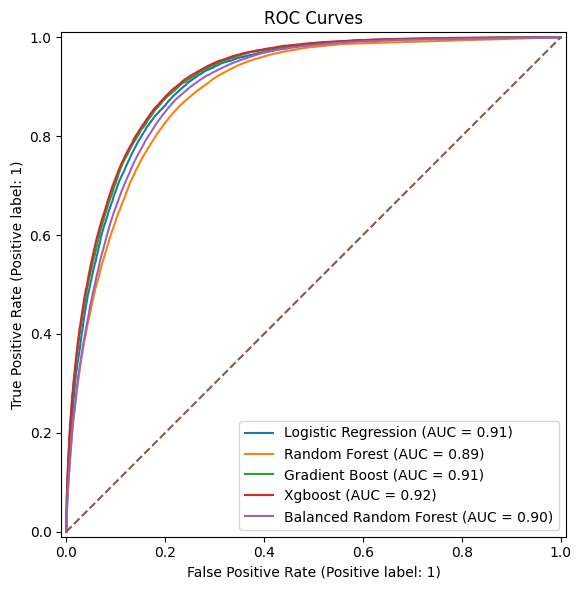

In [37]:
plt.figure(figsize=(8, 6))

for name, result in results.items():
    y_proba = result["probabilities"]
    
    if y_proba is not None:
        RocCurveDisplay.from_predictions(
            y_test,
            y_proba,
            name=name,
            ax=plt.gca()
        )

plt.title("ROC Curves")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.tight_layout()
plt.show()

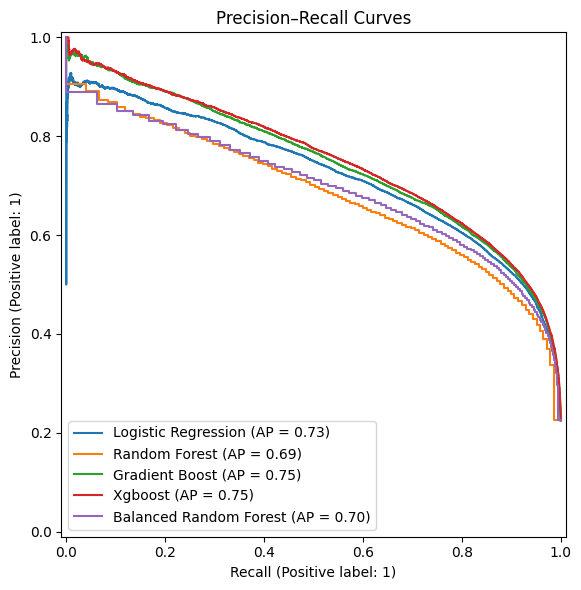

In [40]:
plt.figure(figsize=(8, 6))

for name, result in results.items():
    y_proba = result["probabilities"]
    
    if y_proba is not None:
        PrecisionRecallDisplay.from_predictions(
            y_test,
            y_proba,
            name=name,
            ax=plt.gca()
        )

plt.title("Precision–Recall Curves")
plt.tight_layout()
plt.show()

In [41]:
xgb_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", models["Xgboost"])
])

xgb_pipe

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['g...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=100, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [42]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(xgb_pipe, x, y, cv=cv, scoring='roc_auc', n_jobs=-1)

print("CV ROC-AUC scores:", np.round(cv_scores, 4))
print("Mean:", cv_scores.mean().round(4), "Std:", cv_scores.std().round(4))

CV ROC-AUC scores: [0.9153 0.9165 0.9159 0.9167 0.9143]
Mean: 0.9157 Std: 0.0009


In [43]:
from scipy.stats import randint, uniform, loguniform
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV

In [45]:
xgb_pipeline = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        tree_method="hist",
        device="cuda",
        n_jobs=1
    ))
])

param_dist = {
    "model__n_estimators": randint(200, 1200),
    "model__max_depth": randint(3, 10),
    "model__learning_rate": loguniform(0.01, 0.2),
    "model__subsample": uniform(0.6, 0.4),
    "model__colsample_bytree": uniform(0.6, 0.4),
    "model__min_child_weight": randint(1, 10),
    "model__gamma": uniform(0, 5),
    "model__reg_alpha": loguniform(1e-4, 10),
    "model__reg_lambda": loguniform(1e-3, 10),
    "model__scale_pos_weight": [1.0, 2.0, 3.44, 4.0, 5.0]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

xgb_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=param_dist,
    n_iter=50,
    scoring='roc_auc',
    cv=cv,
    verbose=2,
    n_jobs=1,
    random_state=42,
    refit=True
)
xgb_search.fit(x_train, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV] END model__colsample_bytree=0.749816047538945, model__gamma=4.75357153204958, model__learning_rate=0.08960785365368121, model__max_depth=7, model__min_child_weight=5, model__n_estimators=814, model__reg_alpha=0.01694976823788473, model__reg_lambda=0.002511306167739001, model__scale_pos_weight=3.44, model__subsample=0.9464704583099741; total time=   6.9s
[CV] END model__colsample_bytree=0.749816047538945, model__gamma=4.75357153204958, model__learning_rate=0.08960785365368121, model__max_depth=7, model__min_child_weight=5, model__n_estimators=814, model__reg_alpha=0.01694976823788473, model__reg_lambda=0.002511306167739001, model__scale_pos_weight=3.44, model__subsample=0.9464704583099741; total time=   5.6s
[CV] END model__colsample_bytree=0.749816047538945, model__gamma=4.75357153204958, model__learning_rate=0.08960785365368121, model__max_depth=7, model__min_child_weight=5, model__n_estimators=814, model__reg_alpha=0.

RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('preprocess',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('scaler',
                                                                                                StandardScaler())]),
                                                                               ['SeniorCitizen',
                                                                                'tenure',
                                                                                'MonthlyCharges',
                                                                                'TotalCharges']),
                                                                              ('cat',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleI...
                                        'model__reg_alpha': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7fde75869f70>,
                                        'model__reg_lambda': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7fde75868c20>,
                                        'model__scale_pos_weight': [1.0, 2.0,
                                                                    3.44, 4.0,
                                                                    5.0],
                                        'model__subsample': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7fde7583e1b0>},
                   random_state=42, scoring='roc_auc', verbose=2)

In [47]:
best_xgb_model = xgb_search.best_estimator_
best_xgb_params = xgb_search.best_params_
best_xgb_cv_score = xgb_search.best_score_

y_pred = best_xgb_model.predict(x_test)
y_pred_proba = best_xgb_model.predict_proba(x_test)[:, 1]
test_roc_auc = roc_auc_score(y_test, y_pred_proba)

results["XGBoost Tuned"] = {
    "model": best_xgb_model,
    "accuracy": accuracy_score(y_test, y_pred),
    "predictions": y_pred,
    "probabilities": y_pred_proba
}

print("Best Params:")
print(best_xgb_params)
print("\nBest CV ROC_AUC:")
print(best_xgb_cv_score)
print("\nTest ROC_AUC:")
print(test_roc_auc)

Best Params:
{'model__colsample_bytree': np.float64(0.9208787923016158), 'model__gamma': np.float64(0.3727532183988541), 'model__learning_rate': np.float64(0.19229567074543377), 'model__max_depth': 3, 'model__min_child_weight': 8, 'model__n_estimators': 671, 'model__reg_alpha': np.float64(0.00011759777738127753), 'model__reg_lambda': np.float64(0.006242659053860571), 'model__scale_pos_weight': 3.44, 'model__subsample': np.float64(0.9160702162124823)}

Best CV ROC_AUC:
0.9160005939543578

Test ROC_AUC:
0.9166721022388598


In [48]:
test_df = pd.read_csv("test.csv")

submission = pd.DataFrame({
    "id": test_df["id"],
    "Churn": best_xgb_model.predict_proba(test_df.drop(columns=["id"]))[:, 1]
})

submission.to_csv("submission2.csv", index=False)

print(submission.head())

       id     Churn
0  594194  0.205032
1  594195  0.000654
2  594196  0.292642
3  594197  0.012080
4  594198  0.828830
